# Utility Operations Analytics\n
Portfolio project using synthetic utility data.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

## 1. Load the Dataset

In [3]:
df = pd.read_csv('Midwest_Electric_Utility_Analytics.csv', parse_dates=['Month'])
df.head()

,Customer_ID,Month,Service_Area,Customer_Type,Meter_Type,Avg_Temperature_F,kWh_Usage,Bill_Amount,Payment_Days_Late,Outage_Count,Outage_Minutes,Service_Calls,Injected_Usage_Anomaly
0,C00001,2025-01-01,Central,Residential,Smart Meter,27.0,1115.0,157.38,0,0,0,0,No
1,C00001,2025-02-01,Central,Residential,Smart Meter,32.0,1197.9,167.73,0,0,0,1,No
2,C00001,2025-03-01,Central,Residential,Smart Meter,46.3,1012.0,144.50,0,0,0,0,No
3,C00001,2025-04-01,Central,Residential,Smart Meter,56.6,1067.1,151.39,0,0,0,0,No
4,C00001,2025-05-01,Central,Residential,Smart Meter,65.8,1049.1,149.14,0,1,206,1,No


## 2. Data Quality Checks

In [4]:
print(df.shape)
print(df.dtypes)
print(df.isna().sum())
print('Duplicates:', df.duplicated().sum())

(20000, 13)
Customer_ID                          str
Month                     datetime64[us]
Service_Area                         str
Customer_Type                        str
Meter_Type                           str
Avg_Temperature_F                float64
kWh_Usage                        float64
Bill_Amount                      float64
Payment_Days_Late                  int64
Outage_Count                       int64
Outage_Minutes                     int64
Service_Calls                      int64
Injected_Usage_Anomaly               str
dtype: object
Customer_ID               0
Month                     0
Service_Area              0
Customer_Type             0
Meter_Type                0
Avg_Temperature_F         0
kWh_Usage                 0
Bill_Amount               0
Payment_Days_Late         0
Outage_Count              0
Outage_Minutes            0
Service_Calls             0
Injected_Usage_Anomaly    0
dtype: int64
Duplicates: 0


## 3. Descriptive Statistics

In [5]:
df.describe().round(2)

,Month,Avg_Temperature_F,kWh_Usage,Bill_Amount,Payment_Days_Late,Outage_Count,Outage_Minutes,Service_Calls
count,20000,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00
mean,2025-10-16 02:24:00,57.15,1346.91,177.14,2.41,0.16,10.75,0.16
min,2025-01-01 00:00:00,11.40,372.80,64.60,0.00,0.00,0.00,0.00
25%,2025-05-24 06:00:00,37.80,790.30,116.79,0.00,0.00,0.00,0.00
50%,2025-10-16 12:00:00,58.00,986.40,141.24,0.00,0.00,0.00,0.00
75%,2026-03-08 18:00:00,76.30,1260.93,173.93,0.00,0.00,0.00,0.00
max,2026-08-01 00:00:00,99.00,17076.90,1811.08,30.00,4.00,426.00,6.00
std,NaN,20.36,1222.38,125.99,6.58,0.40,33.42,0.43


## 4. Monthly Electricity Usage

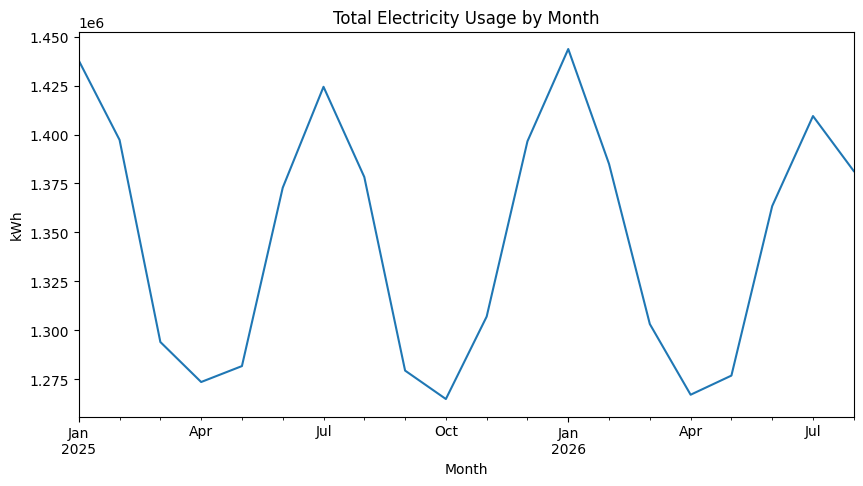

In [6]:
monthly = df.groupby('Month')['kWh_Usage'].sum()
monthly.plot(figsize=(10,5), title='Total Electricity Usage by Month')
plt.ylabel('kWh')
plt.show()

## 5. Outages by Service Area

In [7]:
df.groupby('Service_Area')[['Outage_Count','Outage_Minutes']].sum().sort_values('Outage_Minutes', ascending=False)

,Outage_Count,Outage_Minutes
Service_Area,,
West,776,52340
North,687,47654
South,687,46521
Central,522,35951
East,466,32599


## 6. Temperature and Usage

In [8]:
df[['Avg_Temperature_F','kWh_Usage']].corr().round(3)

,Avg_Temperature_F,kWh_Usage
Avg_Temperature_F,1.000,-0.005
kWh_Usage,-0.005,1.000


## 7. High-Usage Z-Score Flag

In [9]:
mean_usage = df['kWh_Usage'].mean()
std_usage = df['kWh_Usage'].std()
df['Usage_Z_Score'] = (df['kWh_Usage'] - mean_usage) / std_usage
df['High_Usage_Flag'] = df['Usage_Z_Score'].abs() >= 2
df[df['High_Usage_Flag']].sort_values('Usage_Z_Score', ascending=False).head(20)

,Customer_ID,Month,Service_Area,Customer_Type,Meter_Type,Avg_Temperature_F,kWh_Usage,Bill_Amount,Payment_Days_Late,Outage_Count,Outage_Minutes,Service_Calls,Injected_Usage_Anomaly,Usage_Z_Score,High_Usage_Flag
18390,C00920,2025-11-01,East,Commercial,Smart Meter,46.5,17076.9,1811.08,0,0,0,0,Yes,12.868311,True
14862,C00744,2025-03-01,North,Commercial,Smart Meter,45.4,16420.7,1742.17,0,0,0,0,Yes,12.331490,True
19112,C00956,2026-01-01,Central,Commercial,Smart Meter,32.8,14236.2,1512.80,0,0,0,0,Yes,10.544405,True
5408,C00271,2025-09-01,North,Commercial,Smart Meter,59.6,12871.0,1369.46,0,0,0,0,Yes,9.427569,True
14105,C00706,2025-06-01,East,Commercial,Smart Meter,75.4,12793.7,1361.34,13,0,0,0,Yes,9.364332,True
18393,C00920,2026-02-01,East,Commercial,Smart Meter,34.0,12636.9,1344.88,0,0,0,0,Yes,9.236058,True
9723,C00487,2025-04-01,East,Commercial,Smart Meter,59.1,12491.9,1329.65,0,0,0,0,Yes,9.117437,True
5187,C00260,2025-08-01,West,Commercial,Smart Meter,79.6,12332.7,1312.94,0,0,0,0,Yes,8.987199,True
17101,C00856,2025-02-01,East,Commercial,Legacy Meter,32.8,10520.3,1122.63,13,1,71,0,Yes,7.504520,True
6683,C00335,2025-04-01,North,Commercial,Smart Meter,54.8,10007.3,1068.76,0,1,132,0,Yes,7.084847,True


## Business Findings and Recommendations

### Key Findings

1. Electricity usage shows seasonal variation across the analysis period, suggesting that weather and time of year affect customer demand.

2. Outage frequency and outage duration vary by service area, indicating that some areas experience greater service disruption than others.

3. Temperature and electricity usage were analyzed using correlation to determine whether changes in temperature are associated with changes in customer electricity consumption.

4. Z-scores identified unusually high electricity usage records that may warrant additional review.

### Recommendations

- Monitor service areas with consistently high outage counts and outage minutes to identify opportunities for reliability improvements.

- Use unusual-usage alerts to help identify possible meter problems, data-quality issues, or significant changes in customer consumption.

- Track electricity demand alongside weather information to improve operational planning.

- Include outage, usage, billing, and customer-service metrics in an operations dashboard so management can monitor trends and exceptions.